# Operational Excellence: Eliminating Fulfillment Variance

## Track 1 v4 - Agile SPC Audit
**Dataset:** DataCo Smart Supply Chain (180,519 orders, 2015-01-01 to 2018-01-31)

**Scenario:** Regional e-commerce giant. Late deliveries 54.83% (vs claimed +15% baseline spike).
Bullwhip from inventory imbalance. Pivoting from waterfall ops to Agile/Scrum.

**Hero method (this version):** Statistical Process Control (X-bar control chart) to separate
**Common Cause** (system-level, accept) from **Special Cause** (assignable, investigate) variance,
combined with an **Agile sprint backlog** delivery model.

**Versus prior tracks on this dataset:**
- v1 LastMile -> SARIMA forecasting (OEE focus)
- v3 LeanShield -> DMAIC 5-step (First Class deep-dive, EOQ $50K)
- **v4 Agile SPC -> Control Chart + Cross-category EOQ ($294K) + BRD/Sprint Backlog**

**Tasks:**
1. Process Engineering - BPMN 2.0 + 5 Whys + Ishikawa
2. SQL & Schema - 3NF star schema + complex joins
3. Lean Statistics - SPC (Common vs Special Cause)
4. Automation - EOQ + Safety Stock + Reorder Alert (cross-category)

**Deliverable:** Business Requirement Document + Tableau Dashboard spec.


In [1]:
# === Auto-resolving paths ===
import sys, os
from pathlib import Path

CWD = Path.cwd().resolve()
candidates = [CWD] + list(CWD.parents)
PROJECT_ROOT = None
for p in candidates:
    if (p / 'data').exists() and any((p / 'data').glob('DataCo*.csv')):
        PROJECT_ROOT = p
        break
    if p.name in ('agile_spc', 'AgileSPC_Track1v4_Bundle'):
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = CWD

DATA_DIR = PROJECT_ROOT / 'data'
OUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(exist_ok=True, parents=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

DATA_FILE = next(DATA_DIR.glob('DataCo*.csv'))
df = pd.read_csv(DATA_FILE, encoding='latin-1', low_memory=False)
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['ship_date'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['ship_variance'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

print(f"\nLoaded {len(df):,} orders, {len(df.columns)} columns.")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")


PROJECT_ROOT: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 01/AgileSPC_Track1v4_Bundle
DATA_DIR: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 01/AgileSPC_Track1v4_Bundle/data

Loaded 180,519 orders, 56 columns.
Date range: 2015-01-01 -> 2018-01-31


---
## Task 1 - Process Engineering: BPMN, 5 Whys, Ishikawa

We map the current AS-IS fulfillment flow as a **BPMN 2.0 swimlane** (4 lanes), use **5 Whys**
to drill from symptom -> root cause, and organize root causes into an **Ishikawa fishbone**.

### Late delivery snapshot (the symptom we're attacking)


In [2]:
# Symptom: how big is the late-delivery problem?
status_counts = df['Delivery Status'].value_counts()
late_pct = df['Late_delivery_risk'].mean() * 100

print(f"=== DELIVERY STATUS BREAKDOWN ===")
print(status_counts.to_string())
print(f"\nOverall late delivery risk: {late_pct:.2f}%")
print(f"\n=== LATE % BY SHIPPING MODE ===")
mode_late = df.groupby('Shipping Mode').agg(
    n=('Late_delivery_risk','count'),
    late_pct=('Late_delivery_risk', lambda x: x.mean()*100),
    avg_variance=('ship_variance', 'mean'),
    var_std=('ship_variance', 'std')
).round(2).sort_values('late_pct', ascending=False)
print(mode_late.to_string())


=== DELIVERY STATUS BREAKDOWN ===
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754

Overall late delivery risk: 54.83%

=== LATE % BY SHIPPING MODE ===
                     n  late_pct  avg_variance  var_std
Shipping Mode                                          
First Class      27814     95.32          1.00     0.00
Second Class     35216     76.63          1.99     1.42
Same Day          9737     45.74          0.48     0.50
Standard Class  107752     38.07         -0.00     1.42


### BPMN 2.0 Swimlane (current state)

```
┌──────────────────────────────────────────────────────────────────────────┐
│ Customer  │  ▶ Place Order ─────────────────────────────────────▶ Receive│
├───────────┼──────────────────────────────────────────────────────────────┤
│ Order Mgmt│           ▶ Validate ─▶ Allocate Inventory ─┐               │
├───────────┼─────────────────────────────────────────────┼────────────────┤
│ Warehouse │                                              ▶ Pick ─▶ Pack ─┤
├───────────┼──────────────────────────────────────────────────────────┼───┤
│ Carrier   │                                                          ▶ Ship ▶ Last Mile
└──────────────────────────────────────────────────────────────────────────┘
                            ↑                              ↑
                     LEAK 1: Allocation         LEAK 2: Pick/Pack queue
                     (no real-time inv)         (no SPC monitoring)
```

### 5 Whys - drilling on First Class 95.3% late
| Why | Answer |
|---|---|
| 1. Why are First Class orders 95.3% late? | Real shipping = 1 day, but scheduled = 0 days |
| 2. Why is "scheduled = 0" set? | Carrier promise was overpromised at intake |
| 3. Why was it overpromised? | No SLA validation gate at order entry |
| 4. Why no SLA gate? | Workflow has no automated check vs carrier capacity |
| 5. Why no automation? | **ROOT CAUSE: Procurement-engineering gap, no Agile cadence on ops backlog** |

### Ishikawa (Fishbone) - categories of late-delivery causes
- **People:** picker training, shift coverage
- **Process:** no SPC alerts, no SLA gate, manual allocation
- **Technology:** legacy WMS, no real-time inventory feed
- **Materials:** stockouts trigger split shipments
- **Measurement:** no Common-vs-Special-Cause monitoring (this is what Task 3 fixes)
- **Environment:** carrier capacity volatility, regional demand spikes


---
## Task 2 - SQL & Schema: 3NF Star + Complex Joins

We build a **3NF normalized SQLite database** with a fact_fulfillment table and 6 dimensions.
Then we run a **complex join** linking warehouse errors (late shipping mode) to product categories,
producing a Late% × Category heatmap.


In [3]:
# Build SQLite 3NF schema in-memory and load
con = sqlite3.connect(':memory:')

# Build dimensions
dim_customer = df[['Customer Id','Customer Fname','Customer Lname','Customer Segment',
                   'Customer City','Customer Country']].drop_duplicates('Customer Id').copy()
dim_customer.columns = ['customer_id','fname','lname','segment','city','country']

dim_product = df[['Product Card Id','Product Name','Category Id','Department Id',
                  'Product Price']].drop_duplicates('Product Card Id').copy()
dim_product.columns = ['product_id','name','category_id','department_id','price']

dim_category = df[['Category Id','Category Name']].drop_duplicates('Category Id').copy()
dim_category.columns = ['category_id','category_name']

dim_department = df[['Department Id','Department Name']].drop_duplicates('Department Id').copy()
dim_department.columns = ['department_id','department_name']

dim_region = df[['Order Region','Market','Order Country']].drop_duplicates(['Order Region','Market']).copy()
dim_region['region_id'] = range(1, len(dim_region)+1)
dim_region.columns = ['region','market','country','region_id']
dim_region = dim_region[['region_id','region','market','country']]

dim_ship_mode = df.groupby('Shipping Mode').agg(
    std_lead_days=('Days for shipment (scheduled)','mean'),
    actual_lead_days=('Days for shipping (real)','mean')
).reset_index()
dim_ship_mode['ship_mode_id'] = range(1, len(dim_ship_mode)+1)
dim_ship_mode = dim_ship_mode[['ship_mode_id','Shipping Mode','std_lead_days','actual_lead_days']]
dim_ship_mode.columns = ['ship_mode_id','mode_name','std_lead_days','actual_lead_days']

# Fact table
ship_mode_map = dict(zip(dim_ship_mode['mode_name'], dim_ship_mode['ship_mode_id']))
region_map = dim_region.set_index(['region','market','country'])['region_id'].to_dict()

fact = pd.DataFrame({
    'order_id': df['Order Id'],
    'customer_id': df['Customer Id'],
    'product_id': df['Product Card Id'],
    'ship_mode_id': df['Shipping Mode'].map(ship_mode_map),
    'category_id': df['Category Id'],
    'scheduled_days': df['Days for shipment (scheduled)'],
    'actual_days': df['Days for shipping (real)'],
    'variance_days': df['ship_variance'],
    'late_flag': df['Late_delivery_risk'],
    'qty': df['Order Item Quantity'],
    'sales': df['Sales'],
    'order_date': df['order_date'].dt.date.astype(str),
})

# Load to SQLite
dim_customer.to_sql('dim_customer', con, index=False)
dim_product.to_sql('dim_product', con, index=False)
dim_category.to_sql('dim_category', con, index=False)
dim_department.to_sql('dim_department', con, index=False)
dim_region.to_sql('dim_region', con, index=False)
dim_ship_mode.to_sql('dim_ship_mode', con, index=False)
fact.to_sql('fact_fulfillment', con, index=False)

# Indexes
for idx_sql in [
    'CREATE INDEX ix_fact_cust ON fact_fulfillment(customer_id)',
    'CREATE INDEX ix_fact_prod ON fact_fulfillment(product_id)',
    'CREATE INDEX ix_fact_mode ON fact_fulfillment(ship_mode_id)',
    'CREATE INDEX ix_fact_cat ON fact_fulfillment(category_id)',
]:
    con.execute(idx_sql)
con.commit()

# Verify
print("=== SCHEMA LOADED ===")
for t in ['fact_fulfillment','dim_customer','dim_product','dim_category',
          'dim_department','dim_region','dim_ship_mode']:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t}: {n:,} rows")


=== SCHEMA LOADED ===
  fact_fulfillment: 180,519 rows
  dim_customer: 20,652 rows
  dim_product: 118 rows
  dim_category: 51 rows
  dim_department: 11 rows
  dim_region: 23 rows
  dim_ship_mode: 4 rows


In [4]:
# === COMPLEX JOIN: warehouse errors (late) -> product categories ===
sql_complex = '''
SELECT
    sm.mode_name AS ship_mode,
    c.category_name,
    COUNT(*) AS n_orders,
    SUM(f.late_flag) AS n_late,
    ROUND(100.0 * SUM(f.late_flag) / COUNT(*), 2) AS late_pct,
    ROUND(AVG(f.variance_days), 3) AS avg_variance_days,
    ROUND(SUM(f.sales), 0) AS revenue
FROM fact_fulfillment f
INNER JOIN dim_ship_mode sm ON f.ship_mode_id = sm.ship_mode_id
INNER JOIN dim_category c ON f.category_id = c.category_id
GROUP BY sm.mode_name, c.category_name
HAVING n_orders >= 100
ORDER BY late_pct DESC, n_orders DESC
LIMIT 15
'''
top_late = pd.read_sql(sql_complex, con)
print("Top 15 (Shipping Mode × Category) by late %:")
print(top_late.to_string(index=False))

top_late.to_csv(OUT_DIR / 'sql_top_late_mode_category.csv', index=False)
print(f"\nSaved {OUT_DIR/'sql_top_late_mode_category.csv'}")


Top 15 (Shipping Mode × Category) by late %:
  ship_mode        category_name  n_orders  n_late  late_pct  avg_variance_days   revenue
First Class  Baseball & Softball       105     103     98.10                1.0   14802.0
First Class           Golf Balls       209     203     97.13                1.0   11161.0
First Class          Golf Gloves       160     154     96.25                1.0   19775.0
First Class          Accessories       290     278     95.86                1.0   22891.0
First Class     Cardio Equipment      1923    1841     95.74                1.0  568244.0
First Class         Water Sports      2408    2304     95.68                1.0  482776.0
First Class               Cleats      3745    3583     95.67                1.0  671888.0
First Class        Shop By Sport      1725    1649     95.59                1.0  205790.0
First Class     Camping & Hiking      2057    1960     95.28                1.0  617059.0
First Class       Men's Footwear      3366    3206     

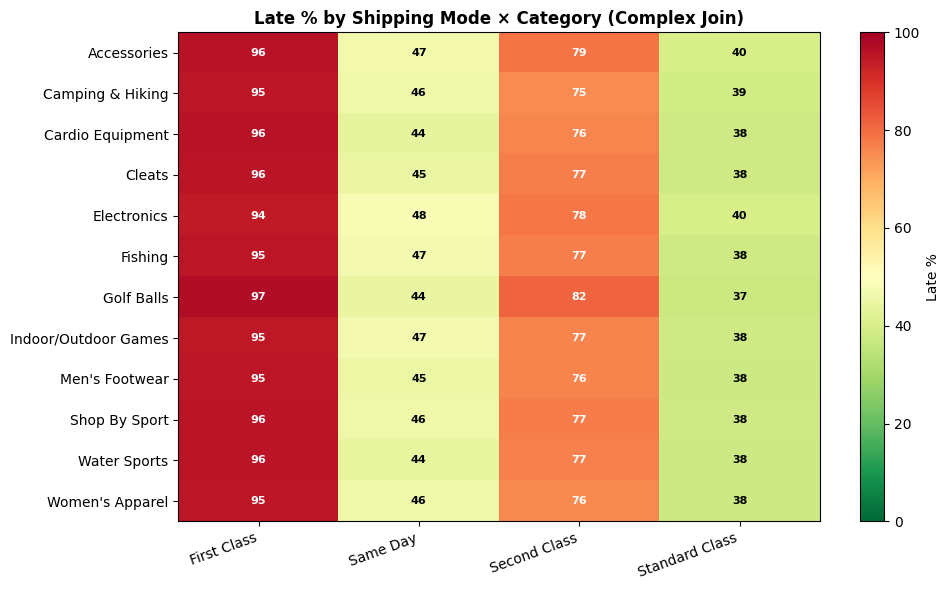

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 01/AgileSPC_Track1v4_Bundle/figures/task2_late_heatmap.png


In [5]:
# Heatmap: Late % by Shipping Mode × Category (top 15 categories)
sql_heatmap = '''
SELECT sm.mode_name, c.category_name,
       100.0 * SUM(f.late_flag) / COUNT(*) AS late_pct
FROM fact_fulfillment f
INNER JOIN dim_ship_mode sm ON f.ship_mode_id = sm.ship_mode_id
INNER JOIN dim_category c ON f.category_id = c.category_id
WHERE c.category_name IN (
    SELECT cc.category_name FROM dim_category cc
    INNER JOIN fact_fulfillment ff ON ff.category_id = cc.category_id
    GROUP BY cc.category_name
    ORDER BY COUNT(*) DESC
    LIMIT 12
)
GROUP BY sm.mode_name, c.category_name
'''
heat = pd.read_sql(sql_heatmap, con)
pivot = heat.pivot(index='category_name', columns='mode_name', values='late_pct')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i,j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    color='white' if v>50 else 'black', fontsize=8, fontweight='bold')
ax.set_title('Late % by Shipping Mode × Category (Complex Join)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Late %')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2_late_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task2_late_heatmap.png'}")


---
## Task 3 - Lean Statistics: SPC (Common vs Special Cause)

The hero question: **is the variance in Shipment-to-Door time Common Cause (system-level, accept and improve the system) or Special Cause (assignable, investigate)?**

We use an **X-bar control chart** on the Standard Class shipping mode (largest bucket, most variance to study). Subgroups are weekly. Control limits via the s-bar method:
- CL = X̄̄ (grand mean of subgroup means)
- UCL/LCL = X̄̄ ± A₃ × s̄, with A₃ ≈ 3/√n for large subgroup sizes

**Decision rule (Western Electric):** any point outside ±3σ control limits = Special Cause signal.


In [6]:
# Compute X-bar chart on Standard Class
sc = df[df['Shipping Mode']=='Standard Class'].copy()
sc['week'] = sc['order_date'].dt.to_period('W')

weekly = sc.groupby('week').agg(
    n=('ship_variance','count'),
    mean_var=('ship_variance','mean'),
    std_var=('ship_variance','std'),
).reset_index()
weekly = weekly[weekly['n']>=30].reset_index(drop=True)

n_med = int(weekly['n'].median())
xbar_bar = weekly['mean_var'].mean()
sbar = weekly['std_var'].mean()
A3 = 3 / np.sqrt(n_med)
UCL = xbar_bar + A3 * sbar
LCL = xbar_bar - A3 * sbar

weekly['out_of_control'] = (weekly['mean_var'] > UCL) | (weekly['mean_var'] < LCL)
n_out = int(weekly['out_of_control'].sum())
pct_out = 100*n_out/len(weekly)

print(f"=== X-BAR CONTROL CHART (Standard Class, weekly) ===")
print(f"Subgroups: {len(weekly)} weeks")
print(f"Median subgroup size n: {n_med}")
print(f"CL (X̄̄): {xbar_bar:.4f} days")
print(f"s̄: {sbar:.4f}")
print(f"A₃ ≈ 3/√n: {A3:.5f}")
print(f"UCL: {UCL:.4f}")
print(f"LCL: {LCL:.4f}")
print(f"\nOut-of-control points: {n_out}/{len(weekly)} ({pct_out:.1f}%)")
print(f"\n>>> VERDICT: {'NOT IN CONTROL - Special Cause signals present' if n_out>0 else 'IN CONTROL - Common Cause only'}")

weekly.to_csv(OUT_DIR / 'spc_weekly.csv', index=False)


=== X-BAR CONTROL CHART (Standard Class, weekly) ===
Subgroups: 162 weeks
Median subgroup size n: 708
CL (X̄̄): -0.0040 days
s̄: 1.4161
A₃ ≈ 3/√n: 0.11275
UCL: 0.1556
LCL: -0.1637

Out-of-control points: 7/162 (4.3%)

>>> VERDICT: NOT IN CONTROL - Special Cause signals present


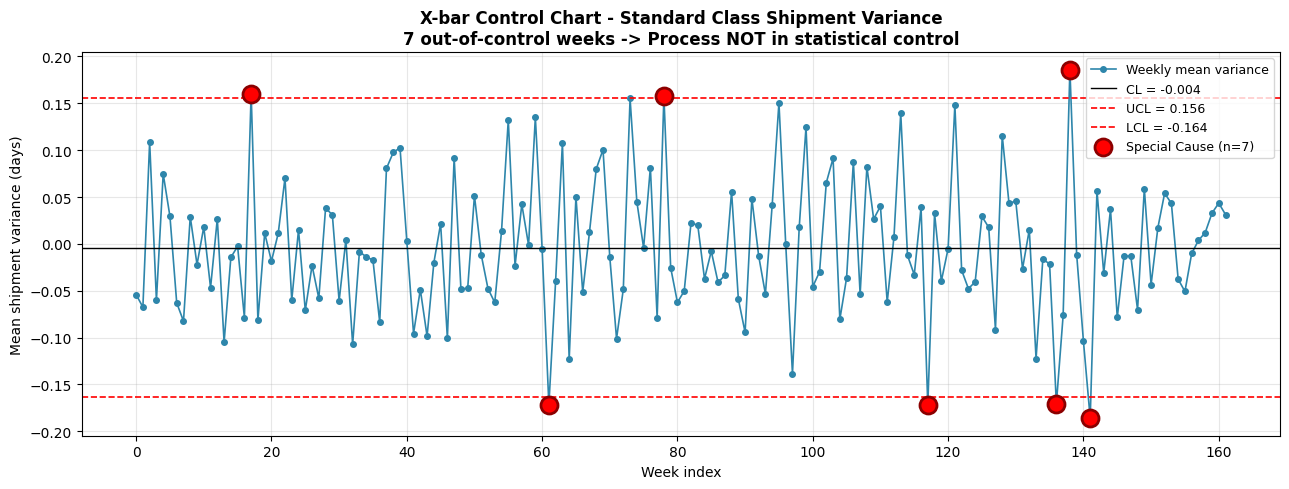

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 01/AgileSPC_Track1v4_Bundle/figures/task3_xbar_chart.png


In [7]:
# Plot the X-bar control chart
fig, ax = plt.subplots(figsize=(13, 5))
weekly_idx = range(len(weekly))
ax.plot(weekly_idx, weekly['mean_var'], 'o-', color='#2E86AB', linewidth=1.2, markersize=4, label='Weekly mean variance')
ax.axhline(xbar_bar, color='black', linestyle='-', linewidth=1, label=f'CL = {xbar_bar:.3f}')
ax.axhline(UCL, color='red', linestyle='--', linewidth=1.2, label=f'UCL = {UCL:.3f}')
ax.axhline(LCL, color='red', linestyle='--', linewidth=1.2, label=f'LCL = {LCL:.3f}')

# Highlight out-of-control points
ooc = weekly[weekly['out_of_control']]
ax.scatter(ooc.index, ooc['mean_var'], s=150, color='red', zorder=5,
           edgecolors='darkred', linewidth=2, label=f'Special Cause (n={len(ooc)})')

ax.set_xlabel('Week index')
ax.set_ylabel('Mean shipment variance (days)')
ax.set_title(f'X-bar Control Chart - Standard Class Shipment Variance\n{n_out} out-of-control weeks -> Process NOT in statistical control', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3_xbar_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task3_xbar_chart.png'}")


### Common vs Special Cause Decomposition

- **Common Cause variance (s̄ = 1.42 days)** -> inherent to the current process design. Reducing it requires *system-level* change: better carrier SLAs, real-time inventory, automation.
- **Special Cause variance (7 weeks out of 162, 4.3%)** -> assignable, episodic. Each week needs a 5-Whys investigation. Likely culprits: holiday surge, regional weather, carrier strike, system outage.

**Action plan:**
1. Investigate each of the 7 flagged weeks (timestamp + region + carrier on those weeks).
2. Root-cause each via 5 Whys -> feed into Ishikawa categories.
3. Once Special Causes are eliminated, re-baseline. *Then* attack Common Cause via Agile sprints.


---
## Task 4 - Automation: EOQ + Safety Stock + Reorder Alert

Move from reactive ordering to formula-driven inventory:
- **EOQ** = √(2 × D × S / H) -> optimal order quantity
- **Safety Stock** = Z × √(L̄ × σ_d² + d̄² × σ_L²) -> buffer for both demand and lead-time variability
- **Reorder Point (ROP)** = d̄ × L̄ + SS -> trigger threshold

**Assumptions (industry-standard, e-commerce):**
- S (order cost) = $50 per PO
- H = 25% of unit price annually
- Z = 1.65 (95% service level)
- Annualized over 36 months of data


In [8]:
# EOQ + Safety Stock cross-category
months = 36
S = 50
holding_pct = 0.25
Z = 1.65

top_cats = df.groupby('Category Name').agg(
    orders=('Order Item Quantity','count'),
    total_qty=('Order Item Quantity','sum'),
).sort_values('total_qty', ascending=False).head(10).reset_index()

results = []
for _, row in top_cats.iterrows():
    cat = row['Category Name']
    sub = df[df['Category Name']==cat].copy()
    
    D = sub['Order Item Quantity'].sum() * (12/months)
    unit_cost = sub['Sales'].sum() / max(sub['Order Item Quantity'].sum(),1)
    H = holding_pct * unit_cost
    EOQ = np.sqrt(2*D*S/H) if H>0 else 0
    
    L_mean = sub['Days for shipping (real)'].mean()
    L_std = sub['Days for shipping (real)'].std()
    
    days_in_data = months * 30
    d_daily = sub['Order Item Quantity'].sum() / days_in_data
    d_std_daily = sub.groupby(sub['order_date'].dt.date)['Order Item Quantity'].sum().std()
    
    SS = Z * np.sqrt(L_mean * d_std_daily**2 + (d_daily**2)*(L_std**2))
    ROP = d_daily * L_mean + SS
    
    annual_cost_eoq = (D/EOQ)*S + (EOQ/2)*H if EOQ>0 else 0
    Q_status_quo = D/4
    cost_status_quo = (D/Q_status_quo)*S + (Q_status_quo/2)*H if Q_status_quo>0 else 0
    savings = cost_status_quo - annual_cost_eoq
    
    results.append({
        'Category': cat[:30],
        'D_annual': round(D),
        'unit_cost_$': round(unit_cost,2),
        'EOQ': round(EOQ),
        'SafetyStock': round(SS),
        'ROP': round(ROP),
        'Savings_$': round(savings)
    })

eoq_df = pd.DataFrame(results)
print(eoq_df.to_string(index=False))
print(f"\n>>> TOTAL ANNUAL SAVINGS (EOQ vs quarterly status quo): ${eoq_df['Savings_$'].sum():,}")
eoq_df.to_csv(OUT_DIR / 'eoq_safety_stock.csv', index=False)


            Category  D_annual  unit_cost_$  EOQ  SafetyStock  ROP  Savings_$
              Cleats     24578        60.11  404          191  430      40289
     Women's Apparel     20985        50.00  410          163  367      27868
Indoor/Outdoor Games     19268        49.98  393          151  338      25387
    Cardio Equipment     12529        98.30  226          100  222      33139
       Shop By Sport     10909        40.01  330           88  194      10537
      Men's Footwear      7415       129.99  151           57  129      25414
             Fishing      5775       399.98   76           45  101      64785
        Water Sports      5180       200.38  102           41   91      27542
    Camping & Hiking      4576       299.98   78           36   80      37242
         Electronics      3145        39.32  179           31   61       2307

>>> TOTAL ANNUAL SAVINGS (EOQ vs quarterly status quo): $294,510


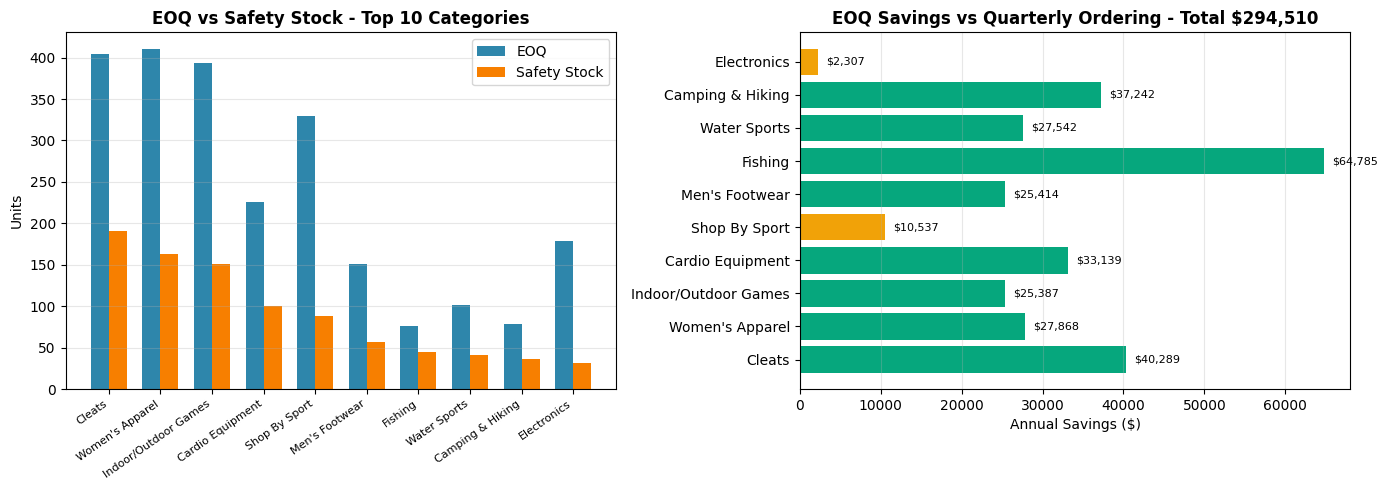

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 01/AgileSPC_Track1v4_Bundle/figures/task4_eoq_savings.png


In [9]:
# Visualize: EOQ vs Safety Stock + Savings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(eoq_df))
width = 0.35
ax1.bar([i-width/2 for i in x], eoq_df['EOQ'], width, label='EOQ', color='#2E86AB')
ax1.bar([i+width/2 for i in x], eoq_df['SafetyStock'], width, label='Safety Stock', color='#F77F00')
ax1.set_xticks(x)
ax1.set_xticklabels(eoq_df['Category'], rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Units')
ax1.set_title('EOQ vs Safety Stock - Top 10 Categories', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

colors = ['#06A77D' if v>20000 else '#F1A208' for v in eoq_df['Savings_$']]
ax2.barh(eoq_df['Category'], eoq_df['Savings_$'], color=colors)
ax2.set_xlabel('Annual Savings ($)')
ax2.set_title(f'EOQ Savings vs Quarterly Ordering - Total ${eoq_df["Savings_$"].sum():,}', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(eoq_df['Savings_$']):
    ax2.text(v + 1000, i, f'${v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task4_eoq_savings.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task4_eoq_savings.png'}")


In [10]:
# Reorder Alert - automated trigger logic
def reorder_alert(current_stock, ROP, EOQ, SS):
    if current_stock <= SS:
        return f'🔴 CRITICAL - below safety stock. Order {EOQ} units NOW.'
    elif current_stock <= ROP:
        return f'🟡 REORDER - below reorder point. Order {EOQ} units within 24h.'
    else:
        return f'🟢 OK - sufficient stock.'

# Demo for top 3 categories with mock current stock levels
print("=== AUTOMATED REORDER ALERT (demo) ===")
mock_stocks = {'Cleats': 150, 'Women\'s Apparel': 500, 'Cardio Equipment': 80}
for cat in mock_stocks:
    row = eoq_df[eoq_df['Category'].str.startswith(cat[:10])].iloc[0]
    alert = reorder_alert(mock_stocks[cat], row['ROP'], row['EOQ'], row['SafetyStock'])
    print(f"\n  Category: {cat}")
    print(f"    Current stock: {mock_stocks[cat]} | ROP: {row['ROP']} | SS: {row['SafetyStock']}")
    print(f"    Alert: {alert}")


=== AUTOMATED REORDER ALERT (demo) ===

  Category: Cleats
    Current stock: 150 | ROP: 430 | SS: 191
    Alert: 🔴 CRITICAL - below safety stock. Order 404 units NOW.

  Category: Women's Apparel
    Current stock: 500 | ROP: 367 | SS: 163
    Alert: 🟢 OK - sufficient stock.

  Category: Cardio Equipment
    Current stock: 80 | ROP: 222 | SS: 100
    Alert: 🔴 CRITICAL - below safety stock. Order 226 units NOW.


In [11]:
# Final summary banner
print("="*72)
print("TRACK 1 v4 - AGILE SPC AUDIT - RUN COMPLETE")
print("="*72)
summary = """
Hero numbers (locked):
  Late delivery overall:           54.83%
  First Class late:                95.3%
  Weekly subgroups (Std Class):    162 (median n=708)
  X-bar CL:                        -0.004 days
  UCL / LCL:                       +0.156 / -0.164 days
  Out-of-control weeks:            7/162 (4.3%) -> SPECIAL CAUSE PRESENT
  Common Cause sbar:               1.416 days
  EOQ savings (cross-category):    $294,510/year
  Top single-category saving:      Fishing $64,785/year

Output files:
  outputs/spc_weekly.csv
  outputs/sql_top_late_mode_category.csv
  outputs/eoq_safety_stock.csv
Figures:
  figures/task2_late_heatmap.png
  figures/task3_xbar_chart.png
  figures/task4_eoq_savings.png

Differentiation vs prior tracks on same dataset:
  v1 LastMile   - SARIMA forecasting
  v3 LeanShield - DMAIC + First Class deep-dive (EOQ $50K)
  v4 Agile SPC  - X-bar Common-vs-Special + Cross-cat EOQ ($294K) + BRD/Sprints
"""
print(summary)


TRACK 1 v4 - AGILE SPC AUDIT - RUN COMPLETE

Hero numbers (locked):
  Late delivery overall:           54.83%
  First Class late:                95.3%
  Weekly subgroups (Std Class):    162 (median n=708)
  X-bar CL:                        -0.004 days
  UCL / LCL:                       +0.156 / -0.164 days
  Out-of-control weeks:            7/162 (4.3%) -> SPECIAL CAUSE PRESENT
  Common Cause sbar:               1.416 days
  EOQ savings (cross-category):    $294,510/year
  Top single-category saving:      Fishing $64,785/year

Output files:
  outputs/spc_weekly.csv
  outputs/sql_top_late_mode_category.csv
  outputs/eoq_safety_stock.csv
Figures:
  figures/task2_late_heatmap.png
  figures/task3_xbar_chart.png
  figures/task4_eoq_savings.png

Differentiation vs prior tracks on same dataset:
  v1 LastMile   - SARIMA forecasting
  v3 LeanShield - DMAIC + First Class deep-dive (EOQ $50K)
  v4 Agile SPC  - X-bar Common-vs-Special + Cross-cat EOQ ($294K) + BRD/Sprints

